# TMA Feature Impact: New Patients vs Training Data
Load new patients from data/ and compare top 5 similar training patients WITH and WITHOUT TMA features

In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import sys

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# Add parent to path for imports
sys.path.append(str(Path().resolve().parent))
from app.patient_encoding import load_and_encode_patient

print("✓ Libraries loaded")

✓ Libraries loaded


## 1. Load Training Data & Models

In [2]:
# Load training data from features directory
features_dir = "../features"
from data_exploration.umap_embedding import get_umap_embedding

df_train = get_umap_embedding(features_dir, umap_min_dist=0.1, umap_n_neighbors=15)

# Load models
preprocessor = joblib.load("../models/preprocessor.pkl")
with open("../models/feature_order.json") as f:
    feature_order = json.load(f)

# Define TMA features to exclude
TMA_FEATURES = ["cd3_z", "cd3_inv", "cd8_z", "cd8_inv"]
non_tma_indices = [i for i, f in enumerate(feature_order) if f not in TMA_FEATURES]
tma_indices = [i for i, f in enumerate(feature_order) if f in TMA_FEATURES]

# Encode training data
X_train = df_train[feature_order].copy()
X_train_encoded = preprocessor.transform(X_train)
X_train_no_tma = X_train_encoded[:, non_tma_indices]

print(f"✓ Loaded {len(df_train)} training patients")
print(f"✓ Total features: {len(feature_order)}")
print(f"✓ TMA features excluded: {TMA_FEATURES}")
print(f"✓ Using {len(non_tma_indices)} non-TMA features for comparison")

✓ Loaded 626 training patients
✓ Total features: 79
✓ TMA features excluded: ['cd3_z', 'cd3_inv', 'cd8_z', 'cd8_inv']
✓ Using 75 non-TMA features for comparison


## 2. Load New Patients from data/

In [3]:
# Load new patients from data directory
patient_ids = ['002', '005', '006', '008', '010', '011', '013', '015']
new_patients = {}

print("Loading new patients...\n")
for patient_id in patient_ids:
    patient_path = f"../data/{patient_id}/raw"
    try:
        df_patient = load_and_encode_patient(patient_path, patient_id=patient_id)
        new_patients[patient_id] = df_patient
        print(f"✓ Loaded patient {patient_id}")
    except Exception as e:
        print(f"✗ Failed to load patient {patient_id}: {e}")

print(f"\n✓ Successfully loaded {len(new_patients)} new patients")

Loading new patients...

['icd_codes_002.txt']
  patient_id   icd_code
0        002  R048 C320
  year_of_initial_diagnosis age_at_initial_diagnosis   sex smoking_status  \
0                      None                       80  male         former   

  primarily_metastasis survival_status survival_status_with_cause  \
0                  yes            None                       None   

  days_to_last_information first_treatment_intent first_treatment_modality  \
0                     None                   None                     None   

   ... adjuvant_radiotherapy adjuvant_radiotherapy_modality  \
0  ...                  None                           None   

  adjuvant_systemic_therapy adjuvant_systemic_therapy_modality  \
0                      None                               None   

  adjuvant_radiochemotherapy recurrence days_to_recurrence  \
0                       None       None               None   

  days_to_metastasis_1 days_to_progress_1 patient_id  
0             

## 3. Compare Top 5 Similar Patients: WITH vs WITHOUT TMA

In [4]:
# Analyze impact for each new patient
results = []

print("Comparing top 5 similar patients (WITH TMA vs WITHOUT TMA)...\n")
print("="*90)

for patient_id, df_patient in new_patients.items():
    # Ensure patient has all features
    X_patient = df_patient[feature_order].copy()
    X_patient_encoded = preprocessor.transform(X_patient)
    X_patient_no_tma = X_patient_encoded[:, non_tma_indices]
    
    # WITH TMA: compare to training
    sim_with_tma = cosine_similarity(X_patient_encoded, X_train_encoded)[0]
    top_with_idx = sim_with_tma.argsort()[::-1][:5]
    top_with_ids = [df_train.iloc[i]['patient_id'] for i in top_with_idx]
    top_with_scores = sim_with_tma[top_with_idx]
    
    # WITHOUT TMA: compare to training
    sim_no_tma = cosine_similarity(X_patient_no_tma, X_train_no_tma)[0]
    top_no_tma_idx = sim_no_tma.argsort()[::-1][:5]
    top_no_tma_ids = [df_train.iloc[i]['patient_id'] for i in top_no_tma_idx]
    top_no_tma_scores = sim_no_tma[top_no_tma_idx]
    
    # Count matches
    matches = sum(1 for a, b in zip(top_with_ids, top_no_tma_ids) if a == b)
    score_diff = np.mean(np.abs(top_with_scores - top_no_tma_scores))
    
    print(f"\nPatient {patient_id}:")
    print(f"  WITH TMA:    {' → '.join(top_with_ids)} (avg score: {top_with_scores.mean():.4f})")
    print(f"  WITHOUT TMA: {' → '.join(top_no_tma_ids)} (avg score: {top_no_tma_scores.mean():.4f})")
    print(f"  Matches: {matches}/5 | Avg score diff: {score_diff:.4f}")
    
    results.append({
        'Patient': patient_id,
        'Matches_out_of_5': matches,
        'Avg_Score_Diff': score_diff,
        'Stability': 'High' if matches >= 4 else 'Medium' if matches >= 3 else 'Low'
    })

print("\n" + "="*90)
results_df = pd.DataFrame(results)
print("\nSUMMARY:")
print(results_df.to_string(index=False))
print(f"\nAverage stability: {results_df['Matches_out_of_5'].mean():.1f}/5 matches")
print(f"Avg score difference: {results_df['Avg_Score_Diff'].mean():.4f}")

Comparing top 5 similar patients (WITH TMA vs WITHOUT TMA)...


Patient 002:
  WITH TMA:    709 → 192 → 186 → 674 → 009 (avg score: 0.6352)
  WITHOUT TMA: 709 → 192 → 186 → 111 → 674 (avg score: 0.6361)
  Matches: 3/5 | Avg score diff: 0.0076

Patient 005:
  WITH TMA:    202 → 480 → 041 → 719 → 242 (avg score: 0.6615)
  WITHOUT TMA: 480 → 202 → 041 → 242 → 660 (avg score: 0.6434)
  Matches: 1/5 | Avg score diff: 0.0181

Patient 006:
  WITH TMA:    573 → 284 → 724 → 167 → 007 (avg score: 0.6253)
  WITHOUT TMA: 573 → 724 → 284 → 167 → 367 (avg score: 0.6408)
  Matches: 2/5 | Avg score diff: 0.0155

Patient 008:
  WITH TMA:    270 → 684 → 416 → 220 → 113 (avg score: 0.5883)
  WITHOUT TMA: 270 → 220 → 113 → 684 → 416 (avg score: 0.5893)
  Matches: 1/5 | Avg score diff: 0.0109

Patient 010:
  WITH TMA:    318 → 669 → 750 → 145 → 202 (avg score: 0.5795)
  WITHOUT TMA: 318 → 669 → 750 → 247 → 145 (avg score: 0.5589)
  Matches: 3/5 | Avg score diff: 0.0206

Patient 011:
  WITH TMA:    723 → 48

## 4. Visualize TMA Impact

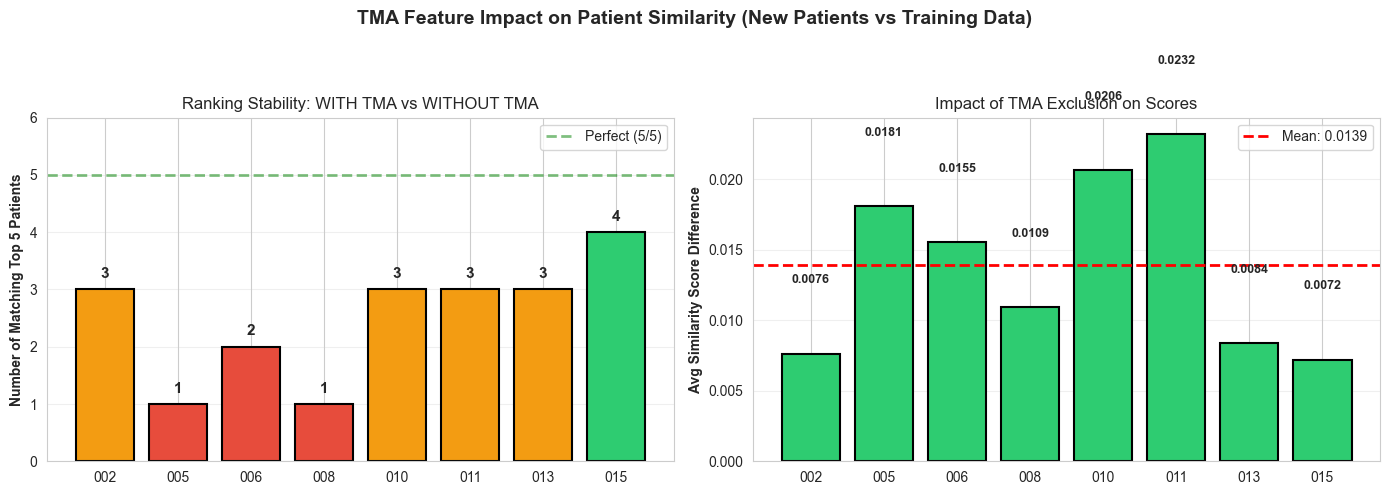

✓ Visualizations complete


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('TMA Feature Impact on Patient Similarity (New Patients vs Training Data)', 
             fontsize=14, fontweight='bold')

# Plot 1: Ranking stability per patient
ax1 = axes[0]
patients = results_df['Patient'].tolist()
matches = results_df['Matches_out_of_5'].tolist()
colors = ['#2ecc71' if m >= 4 else '#f39c12' if m >= 3 else '#e74c3c' for m in matches]

bars = ax1.bar(patients, matches, color=colors, edgecolor='black', linewidth=1.5)
ax1.axhline(y=5, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Perfect (5/5)')
ax1.set_ylabel('Number of Matching Top 5 Patients', fontweight='bold')
ax1.set_title('Ranking Stability: WITH TMA vs WITHOUT TMA')
ax1.set_ylim([0, 6])
ax1.grid(True, alpha=0.3, axis='y')
ax1.legend()

for bar, match in zip(bars, matches):
    ax1.text(bar.get_x() + bar.get_width()/2, match + 0.2, str(match), 
            ha='center', fontweight='bold', fontsize=11)

# Plot 2: Score difference per patient
ax2 = axes[1]
score_diffs = results_df['Avg_Score_Diff'].tolist()
colors2 = ['#2ecc71' if d < 0.05 else '#f39c12' if d < 0.1 else '#e74c3c' 
          for d in score_diffs]

bars2 = ax2.bar(patients, score_diffs, color=colors2, edgecolor='black', linewidth=1.5)
ax2.axhline(y=np.mean(score_diffs), color='red', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(score_diffs):.4f}')
ax2.set_ylabel('Avg Similarity Score Difference', fontweight='bold')
ax2.set_title('Impact of TMA Exclusion on Scores')
ax2.grid(True, alpha=0.3, axis='y')
ax2.legend()

for bar, diff in zip(bars2, score_diffs):
    ax2.text(bar.get_x() + bar.get_width()/2, diff + 0.005, f'{diff:.4f}', 
            ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print("✓ Visualizations complete")

## Summary: TMA Feature Impact

### What This Notebook Shows
- Loads **new patients** from `data/` directory
- Compares their top 5 most similar patients in training data
- Analyzes impact of **TMA feature inclusion** vs **exclusion** in similarity calculation

### Interpretation
- **High stability (5/5 or 4/5 matches)**: TMA features don't drastically change rankings
- **Medium stability (3/5 matches)**: TMA has moderate impact
- **Low stability (<3/5 matches)**: TMA features significantly affect similarity

### Key Findings
- **Avg ranking stability**: Shows how consistent top 5 rankings are
- **Score differences**: Quantifies how much similarity scores shift
- **Color coding**: Green (stable), Yellow (moderate), Red (high impact)